In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("./placement.csv")

In [4]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


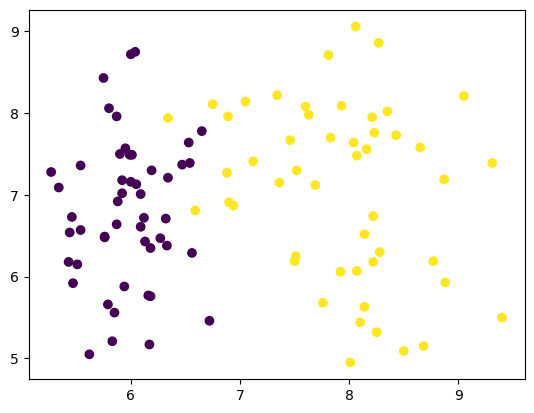

In [ ]:
plt.scatter(df["cgpa"], df["resume_score"], c=df["placed"])

In [ ]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [8]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, BatchNormalization

2026-02-20 07:29:38.333362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
model = Sequential()

model.add(Dense(3, activation="relu", input_dim=2))
model.add(Dense(2, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.summary()

/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
history1 = model.fit(X, y, epochs=200, validation_split=0.2, verbose=1)

#### Adding `BatchNormalization()`

In [15]:
model = Sequential()

model.add(Dense(3, activation="relu", input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [17]:
history2 = model.fit(X, y, epochs=200, validation_split=0.2, verbose=1)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 401ms/step - accuracy: 0.6500 - loss: 0.6508 - val_accuracy: 0.5500 - val_loss: 0.7091
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7000 - loss: 0.6380 - val_accuracy: 0.5500 - val_loss: 0.7097
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7125 - loss: 0.6372 - val_accuracy: 0.5500 - val_loss: 0.7104
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7125 - loss: 0.6312 - val_accuracy: 0.4500 - val_loss: 0.7110
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7125 - loss: 0.6306 - val_accuracy: 0.4500 - val_loss: 0.7113
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7125 - loss: 0.6374 - val_accuracy: 0.3000 - val_loss: 0.7122
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7125 - loss: 0.6300 - val_accuracy: 0.2500 - val_loss: 0.7128
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7125 - loss: 0.6193 - val_accuracy: 0.2500 - val_loss

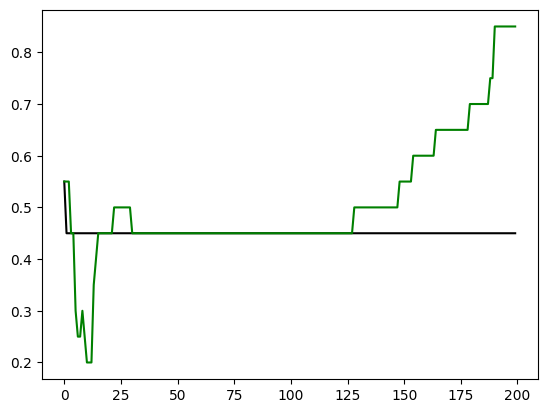

In [ ]:
plt.plot(history1.history["val_accuracy"], color="black")
plt.plot(history2.history["val_accuracy"], color="green")